# Predominance Diagrams and Electrochemical Surface Coverage

## Why this matters

A free-energy diagram follows one reaction pathway. A predominance diagram
instead selects the most stable surface state across potential and pH, while
a coverage model describes how a finite-temperature surface is distributed
among empty sites, adsorbates, and adsorption geometries. Coverage is the
bridge from adsorption thermodynamics to the site balance used in
microkinetics.

You will move from a single Langmuir adsorbate to competing H, H2O, OH, and O
configurations on Pt(111), then examine site degeneracy and
mean-field lateral interactions.

## Learning objectives

By the end of this notebook, you should be able to:

- Convert CHE formation free energies into potential-dependent coverages.
- Derive the Langmuir isotherm from a two-state partition function.
- Treat adsorbates and site geometries as competing configurations.
- Explain the effects of degeneracy and lateral interactions at 298 K.
- Distinguish equilibrium coverage from microkinetic steady-state coverage.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from ipywidgets import FloatSlider, HBox, VBox, interactive_output
from IPython.display import display

right_interact = lambda function, **controls: display(HBox([interactive_output(function, controls), VBox(list(controls.values()))]))

In [2]:
plt.rc("figure", figsize=(8.25/2.54, 8.25/2.54))
plt.rc("figure", dpi=100)
plt.rc("lines",  linewidth=4)
plt.rc("font",   size=10)
plt.rc("font",   family="sans-serif")
plt.rc("axes",   titlesize=10)
plt.rc("axes",   labelsize=9)
plt.rc("xtick",  labelsize=8)
plt.rc("ytick",  labelsize=8)
plt.rc("legend", fontsize=8)
plt.rc("figure", titlesize=10)
colors = ["#1965B0", "#7BAFDE", "#90C987", "#F1932D", "#DC050C"]

boltzmann_constant_ev_k = 8.617333262e-5

## Predominance diagrams: minimal theory

A predominance diagram asks a lowest-state thermodynamic question:
**which candidate surface state has the lowest free energy at each potential
and pH?** It is the surface analogue of selecting the lowest line in a set
of potential-dependent free energies.

For state $i$, define a formation grand free energy relative to the clean
surface,

$$
\Omega_i(U_{\mathrm{RHE}})=\Delta G_i^0+\nu_iU_{\mathrm{RHE}}.
$$

Here $\Delta G_i^0$ is the formation free energy at 0 V versus RHE and
$\nu_i$ is the signed CHE coefficient. In the convention used below,
$\nu=+1$ for H* formation because it consumes one H$^+$+e$^-$ pair,
whereas $\nu=-1$ and $-2$ for OH* and O* formation from water because those
reactions release one and two pairs.

The predominant state is simply

$$
i_{\mathrm{pred}}(U,\mathrm{pH})=\operatorname*{arg\,min}_i\Omega_i.
$$

A boundary between states $i$ and $j$ occurs where

$$
\Omega_i=\Omega_j.
$$

On the RHE scale, the pH dependence of an ideal proton-electron pair is
absorbed into the reference electrode. To draw potential against SHE, use

$$
U_{\mathrm{RHE}}=U_{\mathrm{SHE}}
  +\frac{k_BT\ln 10}{e}\,\mathrm{pH}.
$$

At 298 K the shift is approximately 0.059 V per pH unit. Therefore the same
RHE transition appears as a sloped boundary on a $U_{\mathrm{SHE}}$–pH
diagram.

A predominance diagram includes only the lowest state. It does not report a
mixed coverage, metastability, activation barriers, or rates. Its result is
also conditional on the candidate states supplied to it: an omitted phase
can never appear. For the Pt(111) values used below, each species is
represented by its lowest-energy listed adsorption geometry.


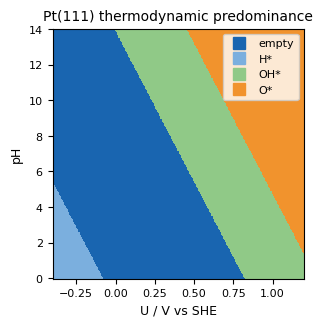

States present in the plotted window: empty, H*, OH*, O*
A candidate absent from the map is never the lowest-energy state.


In [3]:
pt111_predominance_states = pd.DataFrame([ ("empty", 0.00, 0), ("H*", -0.27, +1), ("H2O*", 0.27, 0), ("OH*", 1.02, -1), ("O*", 1.23, -2), ], columns=["state", "dG0_ev", "nu"])


def predominance_map(table, U_SHE_values, pH_values):
    nernst_slope_v = boltzmann_constant_ev_k * 298.0 * np.log(10.0)
    U_SHE_grid, pH_grid = np.meshgrid(U_SHE_values, pH_values)
    U_RHE_grid = U_SHE_grid + nernst_slope_v * pH_grid
    grand_energies_ev = np.stack([ row.dG0_ev + row.nu * U_RHE_grid for row in table.itertuples(index=False) ])
    return np.argmin(grand_energies_ev, axis=0), U_SHE_grid, pH_grid


U_SHE_values = np.linspace(-0.40, 1.20, 401)
pH_values = np.linspace(0.0, 14.0, 281)
predominant, U_SHE_grid, pH_grid = predominance_map(pt111_predominance_states, U_SHE_values, pH_values)

plt.figure()
plt.pcolormesh(U_SHE_grid, pH_grid, predominant, shading="auto", cmap=ListedColormap(colors[:len(pt111_predominance_states)]), vmin=-0.5, vmax=len(pt111_predominance_states) - 0.5)
handles = [ plt.Line2D([], [], marker="s", linestyle="", markersize=8, color=colors[index], label=state) for index, state in enumerate(pt111_predominance_states.state) ]
plt.xlabel("U / V vs SHE")
plt.ylabel("pH")
plt.title("Pt(111) thermodynamic predominance")
plt.legend(handles=handles, loc="upper right")
plt.show()

present_indices = np.unique(predominant)
print("States present in the plotted window:", ", ".join(pt111_predominance_states.state.iloc[present_indices]))
print("A candidate absent from the map is never the lowest-energy state.")


## From adsorption free energy to coverage

Coverage is the fraction of surface sites in a specified state,

$$
\theta_i=\frac{N_i}{N_{\mathrm{sites}}},
\qquad \sum_i\theta_i=1.
$$

Consider one adsorbate A competing with an empty site:

$$
\mathrm{A + * \rightleftharpoons A*}.
$$

If its potential-dependent formation free energy is $\Delta G_A(U)$, the
two-state partition function and probabilities are

$$
Z=1+\exp[-\beta\Delta G_A(U)],
$$

$$
\theta_A=\frac{\exp[-\beta\Delta G_A(U)]}{Z},\qquad
\theta_*=\frac{1}{Z}.
$$

This is the Langmuir isotherm written in free-energy form. It assumes
equilibrium, one adsorbate per site, equivalent sites, and no lateral
interactions. The adsorbate activity has been absorbed into
$\Delta G_A$; equivalently,

$$
\frac{\theta_A}{1-\theta_A}=K_Aa_A,
\qquad K_A=\exp(-\beta\Delta G_A^0).
$$

At $\Delta G_A=0$, equally degenerate empty and occupied states have equal
probability. A more negative formation free energy increases coverage.


In [4]:
def langmuir_coverage(delta_G_ev):
    # Coverage of one adsorbate competing with one empty state.
    beta_ev = 1.0 / (boltzmann_constant_ev_k * 298.0)
    return 1.0 / (1.0 + np.exp(beta_ev * np.asarray(delta_G_ev)))

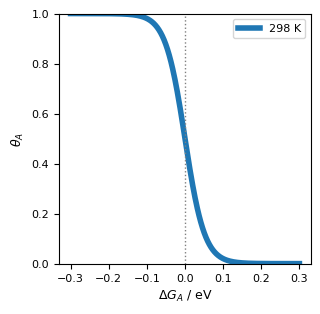

In [5]:
delta_G_grid_ev = np.linspace(-0.30, 0.30, 400)
plt.figure()
plt.plot(delta_G_grid_ev, langmuir_coverage(delta_G_grid_ev), label="298 K")
plt.axvline(0.0, color="0.5", linestyle=":", linewidth=1)
plt.xlabel("$\\Delta G_A$ / eV")
plt.ylabel("$\\theta_A$")
plt.ylim(0, 1)
plt.legend()
plt.show()

> **At 298 K:** The equal-probability point remains at
> $\Delta G_A=0$ when the two states have equal degeneracy.

## Potential-dependent CHE formation energies

Relative to an empty site, the formation energies used here are

$$
\Delta G_{\mathrm{H*}}(U_{\mathrm{RHE}})
   =\Delta G_{\mathrm{H*}}^0+U_{\mathrm{RHE}},
$$

$$
\Delta G_{\mathrm{OH*}}(U_{\mathrm{RHE}})
   =\Delta G_{\mathrm{OH*}}^0-U_{\mathrm{RHE}},
$$

$$
\Delta G_{\mathrm{O*}}(U_{\mathrm{RHE}})
   =\Delta G_{\mathrm{O*}}^0-2U_{\mathrm{RHE}}.
$$

The signs follow the chosen formation reactions: H* consumes one
H$^+$+e$^-$ pair, whereas forming OH* or O* from water releases one or two
pairs. On the RHE scale the pH contribution is already included. For a
fixed SHE potential, use

$$
U_{\mathrm{RHE}}=U_{\mathrm{SHE}}+
\frac{k_BT\ln 10}{e}\,\mathrm{pH}.
$$

If $\Delta G_A(U)=\Delta G_A^0+\nu U$, the coverage depends exponentially
on potential:

$$
\frac{\theta_A}{1-\theta_A}
  =\exp[-\beta(\Delta G_A^0+\nu U)].
$$

For equal degeneracy, half coverage occurs at

$$
U_{1/2}=-\frac{\Delta G_A^0}{\nu}.
$$

Near room temperature, changing $U$ by about 59 mV changes the Boltzmann
ratio of a one-electron equilibrium by a factor of ten. A two-electron
coefficient produces twice the logarithmic potential sensitivity. This is
why ideal non-interacting coverage curves can switch over a narrow potential
interval.


## Competing Pt(111) configurations

Pt(111) exposes top, bridge, fcc, and hcp starting geometries.  These are
not four independent lattices: they overlap on the same surface atoms.  We
therefore let all configurations compete within one representative surface
cell.

The adsorption free energies below are taken from the Pt(111) values
reported by Kolb et al. (2014), cited in the References section. Values are
listed in the order **ontop, hcp, fcc, bridge**. The O bridge site is omitted
because it is unstable in that study. H2O is neutral on the CHE scale, so its
electron coefficient is zero.


In [6]:
# species, site, degeneracy, dG0/eV, electron coefficient
pt111_configurations = pd.DataFrame([ ("H", "top", 1, -0.24, +1), ("H", "hcp", 1, -0.25, +1), ("H", "fcc", 1, -0.27, +1), ("H", "bridge", 3, -0.23, +1), ("H2O", "top", 1, 0.28, 0), ("H2O", "hcp", 1, 0.28, 0), ("H2O", "fcc", 1, 0.27, 0), ("H2O", "bridge", 3, 0.28, 0), ("OH", "top", 1, 1.02, -1), ("OH", "hcp", 1, 1.54, -1), ("OH", "fcc", 1, 1.26, -1), ("OH", "bridge", 3, 1.02, -1), ("O", "top", 1, 2.51, -2), ("O", "hcp", 1, 1.69, -2), ("O", "fcc", 1, 1.23, -2)], columns=["species", "site", "degeneracy", "dG0_ev", "nu"])
pt111_configurations


,species,site,degeneracy,dG0_ev,nu
0,H,top,1,0.18,1
1,H,bridge,3,0.12,1
2,H,fcc,1,0.08,1
3,H,hcp,1,0.10,1
4,OH,top,1,0.96,-1
5,OH,bridge,3,1.08,-1
6,OH,fcc,1,1.12,-1
7,O,bridge,3,1.70,-2
8,O,fcc,1,1.50,-2
9,O,hcp,1,1.58,-2


For mutually exclusive configurations $j$, the partition function is

$$
Z=1+\sum_j g_j\exp[-\beta\Omega_j(U)],
$$

where the first term represents an empty cell, $g_j$ is the degeneracy,
and

$$
\Omega_j(U)=\Delta G_j^0+\nu_jU.
$$

The probability of configuration $j$ is

$$
p_j=\frac{g_j\exp[-\beta\Omega_j]}{Z}.
$$

Degeneracy is equivalent to an entropic stabilization
$-k_BT\ln g_j$: several symmetry-equivalent configurations can collectively
compete with a slightly lower-energy single configuration.

Species coverage is obtained by summing probabilities over sites.  Site
occupancy is obtained by summing over species.  The empty probability plus
every configuration probability must equal one. In this simplified model,
the result is a probability per representative cell; interpreting it as an
absolute monolayer coverage requires a precise definition of the cell and
the number of surface atoms blocked by each configuration.


In [7]:
def configuration_probabilities(table, potential_v, interaction_ev=0.0, tolerance=1e-12, max_iterations=1000):
    # Return equilibrium probabilities for one representative cell.
    beta_ev = 1.0 / (boltzmann_constant_ev_k * 298.0)

    def probabilities_at_coverage(theta):
        grand_energy_ev = (table.dG0_ev.to_numpy() + table.nu.to_numpy() * potential_v + interaction_ev * theta)
        log_weights = (np.log(table.degeneracy.to_numpy()) - beta_ev * grand_energy_ev)
        shift = max(0.0, float(log_weights.max()))
        weights = np.exp(log_weights - shift)
        empty_weight = np.exp(-shift)
        denominator = empty_weight + weights.sum()
        return weights / denominator, empty_weight / denominator

    # Bisection brackets a physical self-consistent root on [0, 1].
    # For attractive W, multiple roots can occur; this selects the bracketed root.
    lower_coverage = 0.0
    upper_coverage = 1.0
    for _ in range(max_iterations):
        theta = 0.5 * (lower_coverage + upper_coverage)
        probabilities, empty_probability = probabilities_at_coverage(theta)
        residual = float(probabilities.sum()) - theta
        if abs(residual) < tolerance:
            break
        if residual > 0.0:
            lower_coverage = theta
        else:
            upper_coverage = theta
    else:
        raise RuntimeError("Coverage iteration did not converge")

    result = table.copy()
    result["grand_energy_ev"] = (result.dG0_ev + result.nu * potential_v + interaction_ev * theta)
    result["probability"] = probabilities
    return result, float(empty_probability)


example, empty_probability = configuration_probabilities(pt111_configurations, potential_v=0.80)
print(f"Empty-cell probability at 0.80 V (vs RHE): {empty_probability:.3f}")
example.sort_values("probability", ascending=False)

Empty-cell probability at 0.80 V (vs RHE): 0.019


,species,site,degeneracy,dG0_ev,nu,grand_energy_ev,probability
8,O,fcc,1,1.50,-2,-0.10,9.380767e-01
9,O,hcp,1,1.58,-2,-0.02,4.161767e-02
7,O,bridge,3,1.70,-2,0.10,1.166697e-03
4,OH,top,1,0.96,-1,0.16,3.759382e-05
5,OH,bridge,3,1.08,-1,0.28,1.053894e-06
6,OH,fcc,1,1.12,-1,0.32,7.399379e-08
2,H,fcc,1,0.08,1,0.88,2.503059e-17
1,H,bridge,3,0.12,1,0.92,1.581656e-17
3,H,hcp,1,0.10,1,0.90,1.148765e-17
0,H,top,1,0.18,1,0.98,5.096481e-19


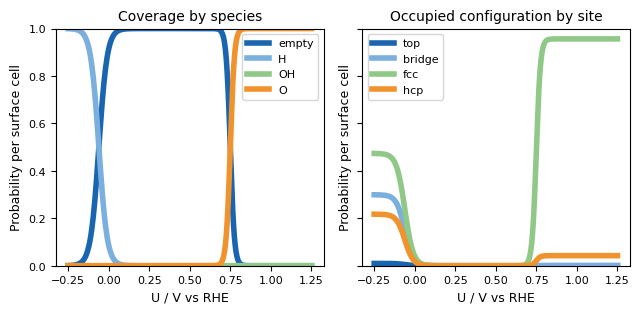

In [8]:
def coverage_curves(table, potential_grid_v, interaction_ev=0.0):
    species_records = []
    site_records = []
    for potential_v in potential_grid_v:
        probabilities, empty = configuration_probabilities(table, potential_v, interaction_ev)
        by_species = probabilities.groupby("species").probability.sum()
        by_site = probabilities.groupby("site").probability.sum()
        species_records.append({"U_RHE": potential_v, "empty": empty, **by_species})
        site_records.append({"U_RHE": potential_v, **by_site})
    return (pd.DataFrame(species_records).fillna(0.0), pd.DataFrame(site_records).fillna(0.0))


potential_grid_v = np.linspace(-0.25, 1.25, 301)
species_coverage, site_coverage = coverage_curves(pt111_configurations, potential_grid_v)

fig, axes = plt.subplots(1, 2, figsize=(2*8.25/2.54, 8.25/2.54), sharey=True)
for index, column in enumerate(["empty", "H", "H2O", "OH", "O"]):
    axes[0].plot(species_coverage.U_RHE, species_coverage[column], color=colors[index], label=column)
for index, column in enumerate(["top", "hcp", "fcc", "bridge"]):
    axes[1].plot(site_coverage.U_RHE, site_coverage[column], color=colors[index], label=column)
axes[0].set_title("Coverage by species")
axes[1].set_title("Occupied configuration by site")
for ax in axes:
    ax.set_xlabel("U / V vs RHE")
    ax.set_ylabel("Probability per surface cell")
    ax.set_ylim(0, 1)
    ax.legend()
fig.tight_layout()
plt.show()


## Experimental Pt(111) comparison

![Capacitance curves generated from cyclic voltammograms of Pt(111)](https://www.researchgate.net/publication/357925522/figure/fig1/AS:1113954285821953@1642598806340/Capacitance-curves-generated-from-cyclic-voltammograms-of-Pt111-in-01-M-HClO-4-pH_W640.jpg)

Reference image: [ResearchGate figure](https://www.researchgate.net/publication/357925522/figure/fig1/AS:1113954285821953@1642598806340/Capacitance-curves-generated-from-cyclic-voltammograms-of-Pt111-in-01-M-HClO-4-pH_W640.jpg).


## Lateral interactions

The independent-cell model changes coverage very sharply because each
configuration feels only its adsorption free energy.  A simple mean-field
repulsion adds $W\theta$ to every occupied configuration:

$$
\Omega_j(U,\theta)=\Delta G_j^0+\nu_jU+W\theta.
$$

This requires a self-consistent solution because the energy depends on the
total occupied fraction.  Positive $W$ penalizes a crowded surface and broadens or shifts coverage
transitions; negative $W$ favors collective occupation and can sharpen them.

> **Pause and predict:** Which changes first when $W$ increases: the identity
> of the lowest-energy adsorbate or the potential at which the surface fills?
>
> **What to look for:** This model changes occupation through a collective
> penalty; it does not contain enough structural information to represent
> ordered adlayers.


In [9]:
def plot_coverage_model(interaction):
    species_coverage, _ = coverage_curves(pt111_configurations, potential_grid_v, interaction_ev=interaction)
    plt.figure()
    for index, column in enumerate(["empty", "H", "H2O", "OH", "O"]):
        plt.plot(species_coverage.U_RHE, species_coverage[column], color=colors[index], label=column)
    plt.xlabel("U / V vs RHE")
    plt.ylabel("Probability per surface cell")
    plt.ylim(0, 1)
    plt.title(f"T = 298 K, W = {interaction:.2f} eV")
    plt.legend()
    plt.show()


right_interact(plot_coverage_model, interaction=FloatSlider(value=0.12, min=-0.30, max=0.30, step=0.01, description="W / eV", continuous_update=False))

## Summary

By working through this notebook, you have practiced how to:

- Derive a Langmuir coverage from a two-state partition function.
- Construct a potential–pH predominance diagram from the lowest grand free
  energy.
- Use CHE electron coefficients to make coverage potential dependent.
- Normalize competing adsorbate and site-configuration probabilities.
- Interpret degeneracy and mean-field lateral interactions at 298 K.
- Separate equilibrium coverage from kinetic steady-state coverage.

## Seminar exercises

1. Replace every illustrative site energy with a consistently corrected
   value and identify which coverage transitions change.
2. Set every degeneracy to one.  Explain which curves move and why.
3. Compare $W=-0.30$, $W=0$, and $W=+0.30$ eV at 298 K.
4. Explain why this overlapping-configuration model should not be described
   as four independent adsorption-site lattices.


## References

- Manuel J. Kolb, Federico Calle-Vallejo, Ludo B. F. Juurlink, and Marc T. M. Koper, "Density functional theory study of adsorption of H2O, H, O, and OH on stepped platinum surfaces," *The Journal of Chemical Physics* **140**, 134708 (2014). [https://doi.org/10.1063/1.4869749](https://doi.org/10.1063/1.4869749)
